Unlike ESG, where several standardised lexicons exist, no academically consolidated lexicon currently captures DEI or AI disclosure in corporate filings. We therefore construct bespoke lexicons grounded in recurring disclosure language observed in 10-K filings, regulatory guidance, and prior empirical studies on corporate signalling.

These terms capture disclosure regimes that are not already in E/S/G, and any residual overlap is explicitly controlled for. They are sized and sub-categorised according to the same structure (100 words / 10 categories) as the standard ESG lexicon. As AI/DEI pillars are addressed separately there is no noise caused by varying total lexicon length.

In [10]:
import yaml
import polars as pl
import plotly.express as px

# Load data
df = pl.read_parquet("spy_10k_2015_present.parquet")

# Load lexicon (regex already defined in YAML)
with open("AI_DEI_Lexicon.yml", "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

ai_patterns  = lex["ai"]
dei_patterns = lex["dei"]

ticker = "AAPL"
section = "risk_factors"

plot_df = (
    df
    .filter((pl.col("ticker") == ticker) & (pl.col("section") == section))
    .sort("filing_date")
    .with_columns(
        # Sum regex hits across all AI patterns
        pl.sum_horizontal(
            [pl.col("text").str.count_matches(p) for p in ai_patterns]
        ).alias("AI"),

        # Sum regex hits across all DEI patterns
        pl.sum_horizontal(
            [pl.col("text").str.count_matches(p) for p in dei_patterns]
        ).alias("DEI"),
    )
    .select(["filing_date", "AI", "DEI"])
    .to_pandas()
)

fig = px.line(
    plot_df,
    x="filing_date",
    y=["AI", "DEI"],
    title=f"AI vs DEI Lexicon Occurrences — {ticker} ({section})",
    labels={"value": "Count", "filing_date": "Filing Date"},
    markers=True,
)

fig.update_layout(template="plotly_white")
fig.update_yaxes(tickmode="linear", tick0=0, dtick=1)
fig.show()


In [16]:
import re
import yaml
import polars as pl
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "vscode"

TICKER = "AAPL"
START_YEAR = 2015
END_YEAR = 2024

LEXICON_FILE = "AI_DEI_Lexicon.yml"
PARQUET_FILE = "spy_10k_2015_present.parquet"

with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

AI_PATTERNS = lex["ai"]
DEI_PATTERNS = lex["dei"]

df = pl.read_parquet(PARQUET_FILE, columns=["ticker", "filing_period", "text"])

df = (
    df.with_columns(
        pl.col("filing_period").cast(pl.Date),
        pl.col("filing_period").dt.year().alias("year"),
    )
    .filter(
        (pl.col("ticker") == TICKER)
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
        & pl.col("text").is_not_null()
    )
)

# What this does: turn common ESG-style regex into readable labels
def regex_to_label(p: str) -> str:
    s = p

    # Strip inline flag and common anchors
    s = re.sub(r"^\(\?i\)", "", s)
    s = s.replace(r"\b", "")
    s = s.strip()

    # Turn common “space/hyphen” patterns into spaces
    s = s.replace(r"[-\s]+", " ").replace(r"[-\s]", " ")

    # Remove escaping that makes it unreadable
    s = s.replace(r"\.", ".").replace(r"\-", "-").replace(r"\s", " ")

    # Remove basic grouping syntax for display
    s = re.sub(r"\(\?:", "(", s)          # non-capturing -> capturing (display)
    s = re.sub(r"\(\s*\)", "", s)         # empty groups
    s = re.sub(r"[()]", "", s)            # drop parentheses
    s = s.replace("?:", "")

    # Clean quantifiers that are just plural markers
    s = s.replace("s?", "s")
    s = re.sub(r"\{\d+,?\d*\}", "", s)    # drop {m,n}

    # Collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()

    # Small cosmetics
    s = s.replace("a.i.", "A.I.")
    if s.lower() == "ai":
        return "AI"
    if s.lower() == "dei":
        return "DEI"
    if s.lower() == "llm s" or s.lower() == "llms":
        return "LLMs"

    return s

def plot_bucket(bucket_name: str, patterns: list[str]):
    cols = [f"t_{i:03d}" for i in range(len(patterns))]

    tmp = df.with_columns(
        [pl.col("text").str.count_matches(patterns[i]).alias(cols[i]) for i in range(len(patterns))]
    )

    wide = (
        tmp.group_by("year")
          .agg([pl.sum(c).alias(c) for c in cols])
          .sort("year")
    )

    # What this does: compute total hits per term over all years
    totals = []
    for i, c in enumerate(cols):
        total = wide.select(pl.col(c).sum()).item()
        total = 0 if total is None else int(total)
        if total > 0:
            totals.append((i, c, total))

    if not totals:
        print(f"{bucket_name}: no non-zero terms for {TICKER} in {START_YEAR}-{END_YEAR}")
        return

    # What this does: choose 6–8 labels (top by total hits)
    totals.sort(key=lambda x: x[2], reverse=True)
    k = len(totals)
    top_n = min(8, k)
    if top_n < 6:
        top_n = k  # if fewer than 6 non-zero terms exist, just show what's there

    keep = totals[:top_n]

    # What this does: build readable labels; ensure uniqueness
    used = set()
    rename_map = {}
    for i, c, _ in keep:
        base = regex_to_label(patterns[i])
        label = base
        j = 2
        while label.lower() in used:
            label = f"{base} ({j})"
            j += 1
        used.add(label.lower())
        rename_map[c] = label

    plot_df = (
        wide.select(["year"] + [c for _, c, _ in keep])
            .rename(rename_map)
            .to_pandas()
            .melt(id_vars="year", var_name="term", value_name="count")
    )

    fig = px.line(
        plot_df,
        x="year",
        y="count",
        color="term",
        markers=True,
        title=f"{bucket_name} Term Occurrences in {TICKER} 10-K (Entire Report, {START_YEAR}–{END_YEAR})",
        labels={"year": "Filing Year", "count": "Occurrences", "term": f"{bucket_name} Term"},
    )
    fig.update_layout(template="plotly_white", hovermode="x unified")
    fig.update_xaxes(tickmode="linear", tick0=START_YEAR, dtick=1)
    fig.update_yaxes(tickmode="linear", tick0=0)
    fig.show()

plot_bucket("AI", AI_PATTERNS)
plot_bucket("DEI", DEI_PATTERNS)


AAPL historically talks product experience, design, and platform integration far more than it talks “AI” explicitly. Even when they are using ML heavily, they frame it as features (camera quality, on-device intelligence, privacy-preserving UX) rather than as “AI strategy”. So only 3–4 AI terms surviving across the full report is totally consistent with how Apple writes.

In practical terms, in 2015–2019 corporate filings generally didn’t use explicit DEI terminology as often as later years, even if the company had internal DEI policies.
Before 2020:

Human capital disclosure was largely prescriptive and minimal

Firms disclosed headcount, nothing more

Workforce composition, diversity, equity, inclusion → implicitly non-material

After August 2020:

The SEC replaced prescriptive rules with a principles-based requirement

Firms must disclose human capital measures that are material to their business

Crucially: the definition of “material” was left to firms and investors



In [20]:
import polars as pl
import plotly.express as px
import plotly.io as pio
import yaml
import re

pio.renderers.default = "vscode"

LEXICON_FILE = "AI_DEI_Lexicon.yml"   # or "AI_DEI_Lexicon.yml"
PARQUET_FILE = "spy_10k_2015_present.parquet"
TICKER = "AAPL"
TOP_N = 20

with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

buckets = {
    "AI": list(lex.get("ai") or []),     # list[str] regex patterns
    "DEI": list(lex.get("dei") or []),   # list[str] regex patterns
}

# What this does: make clean display labels so regex doesn't appear on y-axis
def regex_to_label(pat: str) -> str:
    s = pat
    s = re.sub(r"^\(\?i\)", "", s)           # drop inline flag
    s = s.replace(r"\b", "")                 # drop word boundaries
    s = s.replace(r"[-\s]+", " ")            # common ESG lexicon spacing
    s = s.replace(r"[-\s]", " ")
    s = s.replace("?:", "")                  # non-capturing group marker
    s = re.sub(r"[()]", "", s)               # drop parentheses
    s = s.replace("s?", "s")                 # plural quantifier -> plural
    s = re.sub(r"\{\d+,?\d*\}", "", s)       # drop {m,n}
    s = re.sub(r"\s+", " ", s).strip()       # collapse whitespace

    # What this does: small readability overrides
    lower = s.lower()
    overrides = {
        "ai": "AI",
        "a.i.": "A.I.",
        "artificial intelligence": "Artificial intelligence",
        "machine learning": "Machine learning",
        "deep learning": "Deep learning",
        "natural language processing": "Natural language processing",
        "large language model s": "Large language models",
        "large language models": "Large language models",
        "diversity equity inclusion": "Diversity, equity & inclusion",
        "dei": "DEI",
        "equal employment opportunity": "Equal employment opportunity",
        "non discrimination": "Non-discrimination",
    }
    if lower in overrides:
        return overrides[lower]

    return s[:70] + ("…" if len(s) > 70 else "")

# Only AAPL text (lazy) to keep it light
START_YEAR = 2015
END_YEAR = 2024

base = (
    pl.scan_parquet(PARQUET_FILE)
      .select(["ticker", "filing_period", "text"])
      .filter(pl.col("ticker") == TICKER)
      .with_columns(
          pl.col("filing_period").cast(pl.Date),
          pl.col("filing_period").dt.year().alias("year"),
          pl.col("text").cast(pl.Utf8).fill_null("").alias("text"),
      )
      .filter(
          (pl.col("year") >= START_YEAR) &
          (pl.col("year") <= END_YEAR)
      )
      .select("text")
)


rows = []
chunk_size = 50

for bucket, patterns in buckets.items():
    if not patterns:
        continue

    for start in range(0, len(patterns), chunk_size):
        chunk = patterns[start:start + chunk_size]

        exprs = [
            pl.col("text").str.count_matches(pat).sum().alias(f"t{i}")
            for i, pat in enumerate(chunk)
        ]

        out = base.select(exprs).collect()

        for i, pat in enumerate(chunk):
            rows.append(
                {
                    "bucket": bucket,
                    "term": regex_to_label(pat),  # clean y-axis label
                    "regex": pat,                 # keep raw regex for hover/audit
                    "total_occurrences": int(out.item(0, i)),
                }
            )

freq = (
    pl.DataFrame(rows)
      .filter(pl.col("total_occurrences") > 0)  # drop zero-occurrence terms
      .sort(["bucket", "total_occurrences"], descending=[False, True])
)

plot_df = freq.to_pandas()

for bucket in ["AI", "DEI"]:
    sub = (
        plot_df[plot_df["bucket"] == bucket]
        .sort_values("total_occurrences", ascending=False)
        .head(TOP_N)
    )

    fig = px.bar(
        sub,
        y="term",
        x="total_occurrences",
        orientation="h",
        title=f"Top {TOP_N} {bucket} Terms by Total Occurrences ({TICKER} only)",
        labels={"term": "Term", "total_occurrences": "Total Occurrences"},
        hover_data={"regex": True},   # regex only on hover
    )

    fig.update_layout(template="plotly_white", showlegend=False)
    fig.update_yaxes(categoryorder="total ascending")
    fig.show()


In [22]:
import polars as pl
import plotly.express as px
import plotly.io as pio
import yaml

pio.renderers.default = "vscode"

PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "AI_DEI_Lexicon.yml"
SECTOR = "Information Technology"
START_YEAR = 2015
END_YEAR = 2024
TOP_N = 15
CHUNK_SIZE = 30
Y_MAX = 90  # fixed max

with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

buckets = {
    "AI": list(lex.get("ai") or []),
    "DEI": list(lex.get("dei") or []),
}

base = (
    pl.scan_parquet(PARQUET_FILE)
      .select(["cik", "gics_sector", "filing_period", "text"])
      .with_columns(
          pl.col("cik").cast(pl.Utf8),
          pl.col("gics_sector").cast(pl.Utf8),
          pl.col("filing_period").cast(pl.Date),
          pl.col("text").cast(pl.Utf8).fill_null(""),
          pl.col("filing_period").cast(pl.Date).dt.year().alias("year"),
      )
      .filter(
          (pl.col("gics_sector") == SECTOR)
          & (pl.col("year") >= START_YEAR)
          & (pl.col("year") <= END_YEAR)
          & pl.col("cik").is_not_null()
      )
      .select(["cik", "year", "text"])
)

def year_term_counts(patterns: list[str]) -> pl.DataFrame:
    if not patterns:
        return pl.DataFrame({"year": []})

    parts = []
    for start in range(0, len(patterns), CHUNK_SIZE):
        chunk = patterns[start:start + CHUNK_SIZE]
        cols = [f"t{start+i:03d}" for i in range(len(chunk))]

        with_terms = (
            base.with_columns([pl.col("text").str.contains(p).alias(c) for p, c in zip(chunk, cols)])
                .select(["cik", "year"] + cols)
        )

        # What this does: collapse multiple rows per firm-year (any section hit -> 1)
        firm_year = with_terms.group_by(["cik", "year"]).agg([pl.max(c).alias(c) for c in cols])

        # What this does: count firms with term present per year
        parts.append(
            firm_year.group_by("year")
                     .agg([pl.sum(c).cast(pl.Int64).alias(c) for c in cols])
                     .sort("year")
                     .collect()
        )

    out = parts[0]
    for part in parts[1:]:
        out = out.join(part, on="year", how="inner")
    return out

def plot_bucket(patterns: list[str], bucket_name: str):
    counts = year_term_counts(patterns)
    if counts.is_empty():
        return

    id_to_pattern = {f"t{i:03d}": patterns[i] for i in range(len(patterns))}

    long_df = (
        counts.melt(id_vars="year", variable_name="term_id", value_name="n_firms_with_term")
              .with_columns(pl.col("term_id").replace(id_to_pattern).alias("pattern"))
    )

    totals = (
        long_df.group_by("pattern")
               .agg(pl.sum("n_firms_with_term").alias("total"))
               .sort("total", descending=True)
    )

    top_patterns = totals.head(TOP_N).get_column("pattern").to_list()
    plot_df = long_df.filter(pl.col("pattern").is_in(top_patterns)).to_pandas()

    fig = px.line(
        plot_df,
        x="year",
        y="n_firms_with_term",
        color="pattern",
        markers=True,
        title=f"{SECTOR}: firms with term present ({bucket_name}, {START_YEAR}–{END_YEAR})",
        labels={"year": "Year", "n_firms_with_term": "Firms with term present"},
    )

    fig.update_layout(template="plotly_white", hovermode="x unified", showlegend=False)
    fig.update_xaxes(tickmode="linear", tick0=START_YEAR, dtick=1)
    fig.update_yaxes(tickmode="linear", tick0=0, dtick=10, range=[0, Y_MAX])
    fig.show()

for bucket_name, patterns in buckets.items():
    plot_bucket(patterns, bucket_name)


C:\Users\ddddd\AppData\Local\Temp\ipykernel_10612\2624612858.py:82: DeprecationWarning:

`DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`



C:\Users\ddddd\AppData\Local\Temp\ipykernel_10612\2624612858.py:82: DeprecationWarning:

`DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`



1. AI (Information Technology sector)

Pattern

2015–2017: low, flat adoption across firms

2018–2019: early dispersion — some firms move, most don’t

2020 onward: broad take-off

2023–2024: convergence at high levels, with heterogeneity across terms

Interpretation

This is technology diffusion, not compliance.

Firms adopt AI language as capabilities mature, not because they’re required to.

The spread across terms (multiple rising lines) tells you firms are:

adopting different AI narratives

not copying a single boilerplate phrase

Key contrast with AAPL

Apple’s AI plot was sparse and late.

The IT sector as a whole is explicitly AI-forward.

That validates your use of AAPL as a low-AI disclosure control.

2. DEI (Information Technology sector)

Pattern

2015–2018: non-zero baseline (unlike AI)

Sharp, synchronous jump in 2020–2021

Post-2021: plateauing and mild consolidation

Interpretation

This is regime change, not gradual adoption.

The near-simultaneous rise across many DEI terms indicates:

institutionalisation

templated disclosure

shared compliance logic

Key contrast with AI

DEI rises together, AI rises unevenly.

That’s exactly the distinction between:

normative disclosure (DEI)

capability disclosure (AI)

In [24]:
import math
import polars as pl
import plotly.express as px
import plotly.io as pio
import yaml

pio.renderers.default = "vscode"

PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "AI_DEI_Lexicon.yml"
SECTOR = "Information Technology"
START_YEAR = 2015
END_YEAR = 2024

CHUNK_SIZE = 15
DF_CAP_SHARE = 0.95  # optional: ignore ultra-common terms (idf ~ 1 anyway)

with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

buckets = {
    "AI": list(lex.get("ai") or []),
    "DEI": list(lex.get("dei") or []),
}

# Firm-year documents (entire report)
df = pl.read_parquet(PARQUET_FILE, columns=["cik", "gics_sector", "filing_period", "text"])

docs = (
    df.with_columns(
        pl.col("cik").cast(pl.Utf8),
        pl.col("gics_sector").cast(pl.Utf8),
        pl.col("filing_period").cast(pl.Date),
        pl.col("text").cast(pl.Utf8).fill_null(""),
        pl.col("filing_period").cast(pl.Date).dt.year().alias("year"),
    )
    .filter(
        (pl.col("gics_sector") == SECTOR)
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
        & pl.col("cik").is_not_null()
    )
    .group_by(["cik", "year"])
    .agg(pl.col("text").str.concat("\n").alias("text"))
    .with_columns(
        pl.col("text").str.count_matches(r"(?i)\b\w+\b").alias("n_words")
    )
    .filter(pl.col("n_words") > 0)
)

N = int(docs.select(pl.len()).item())

def bucket_year_mean_tfidf(docs_df: pl.DataFrame, patterns: list[str]) -> pl.DataFrame:
    if not patterns or N == 0:
        return pl.DataFrame({"year": [], "mean_tfidf": []})

    out = docs_df.select(["year", "text", "n_words"]).with_columns(pl.lit(0.0).alias("tfidf_sum"))

    for start in range(0, len(patterns), CHUNK_SIZE):
        chunk = patterns[start:start + CHUNK_SIZE]
        cnt_cols = [f"c{start+i:03d}" for i in range(len(chunk))]

        tmp = out.with_columns(
            [pl.col("text").str.count_matches(pat).alias(col) for pat, col in zip(chunk, cnt_cols)]
        )

        idf_vals = []
        for col in cnt_cols:
            df_i = int(tmp.select((pl.col(col) > 0).sum()).item())
            if df_i / N >= DF_CAP_SHARE:
                idf_vals.append(0.0)
            else:
                idf_vals.append(math.log((N + 1) / (df_i + 1)) + 1.0)

        tfidf_chunk = None
        for col, idf in zip(cnt_cols, idf_vals):
            if idf == 0.0:
                continue
            term_expr = (pl.col(col).cast(pl.Float64) / pl.col("n_words").cast(pl.Float64)) * pl.lit(idf)
            tfidf_chunk = term_expr if tfidf_chunk is None else (tfidf_chunk + term_expr)

        if tfidf_chunk is None:
            out = tmp.drop(cnt_cols)
        else:
            out = (
                tmp.with_columns((pl.col("tfidf_sum") + tfidf_chunk).alias("tfidf_sum"))
                   .drop(cnt_cols)
            )

    return (
        out.group_by("year")
           .agg(pl.mean("tfidf_sum").alias("mean_tfidf"))
           .sort("year")
    )

series = []
for bucket_name, pats in buckets.items():
    yr = bucket_year_mean_tfidf(docs, pats).with_columns(pl.lit(bucket_name).alias("bucket"))
    series.append(yr)

plot_df = pl.concat(series).to_pandas()

fig = px.line(
    plot_df,
    x="year",
    y="mean_tfidf",
    color="bucket",
    markers=True,
    title=f"{SECTOR}: Mean TF–IDF of AI vs DEI lexicon (firm-year docs, {START_YEAR}–{END_YEAR})",
    labels={"year": "Year", "mean_tfidf": "Mean TF–IDF", "bucket": "Bucket"},
)

fig.update_layout(template="plotly_white", hovermode="x unified")
fig.update_xaxes(tickmode="linear", tick0=START_YEAR, dtick=1)
fig.show()


C:\Users\ddddd\AppData\Local\Temp\ipykernel_10612\553735807.py:44: DeprecationWarning:

`str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.



Within the Information Technology sector, DEI-related disclosure exhibits a sharp increase in mean TF-IDF beginning in 2020, followed by stabilisation, consistent with the institutionalisation and standardisation of DEI language across firms. In contrast, AI-related disclosure shows a more gradual increase prior to 2020, followed by rapid acceleration after 2022, ultimately surpassing DEI by 2024. This pattern suggests that AI disclosure is increasingly firm-specific and capability-driven, whereas DEI disclosure reflects an earlier regime shift toward standardised reporting.

C:\Users\ddddd\AppData\Local\Temp\ipykernel_10612\1529324096.py:60: DeprecationWarning:

`str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.



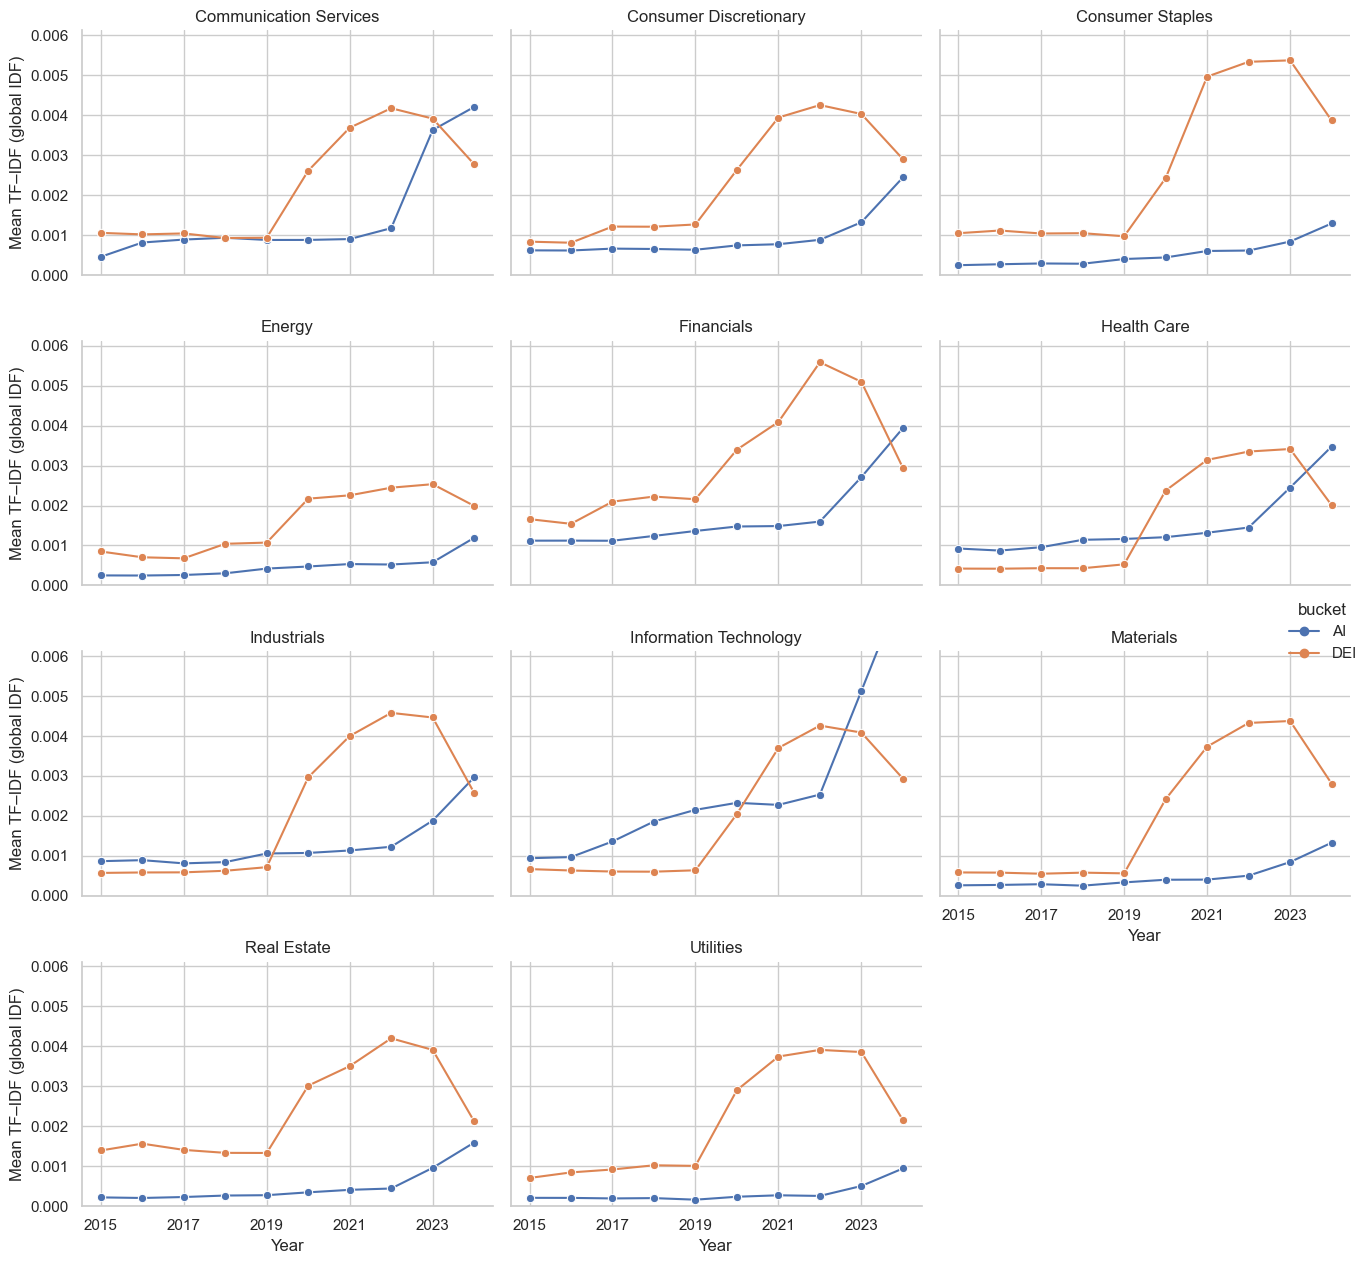

In [26]:
import math
import polars as pl
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------
# Config
# --------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "AI_DEI_Lexicon.yml"   # or "AI_DEI_Lexicon.yml"
START_YEAR = 2015
END_YEAR = 2024

CHUNK_SIZE = 12          # smaller = lower RAM, slower
MIN_DOCS = 80            # keep only "real" sector panels (firm-year docs)
DF_CAP_SHARE = 0.98      # drop ultra-common terms (idf ~ 1, mostly boilerplate)

# --------------------
# Load lexicon (regex patterns)
# --------------------
with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

buckets = {
    "AI": list(lex.get("ai") or []),
    "DEI": list(lex.get("dei") or []),
}

# Flatten term list with bucket labels
terms = []
for bucket, pats in buckets.items():
    for pat in pats:
        terms.append((bucket, pat))

# --------------------
# Build firm-year documents for whole universe (entire report)
# --------------------
df = pl.read_parquet(
    PARQUET_FILE,
    columns=["cik", "gics_sector", "filing_period", "text"],
)

docs = (
    df.with_columns(
        pl.col("cik").cast(pl.Utf8),
        pl.col("gics_sector").cast(pl.Utf8),
        pl.col("filing_period").cast(pl.Date),
        pl.col("text").cast(pl.Utf8).fill_null(""),
        pl.col("filing_period").cast(pl.Date).dt.year().alias("year"),
    )
    .filter(
        pl.col("gics_sector").is_not_null()
        & pl.col("cik").is_not_null()
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
    )
    .group_by(["cik", "gics_sector", "year"])
    .agg(pl.col("text").str.concat("\n").alias("text"))
    .with_columns(
        pl.col("text").str.count_matches(r"(?i)\b\w+\b").alias("n_words")  # TF denominator
    )
    .filter(pl.col("n_words") > 0)
)

N = int(docs.select(pl.len()).item())
if N == 0:
    raise RuntimeError("No firm-year documents found after filtering years/sector/cik.")

# What this does: keep only sectors with enough firm-year coverage (so you get ~10–11 panels)
sector_sizes = docs.group_by("gics_sector").agg(pl.len().alias("n_docs"))
keep_sectors = (
    sector_sizes.filter(pl.col("n_docs") >= MIN_DOCS)
                .get_column("gics_sector")
                .to_list()
)
docs = docs.filter(pl.col("gics_sector").is_in(keep_sectors))

N = int(docs.select(pl.len()).item())  # update N after dropping small sectors

# --------------------
# Compute bucket TF-IDF per firm-year (global IDF across all kept sectors)
# --------------------
docs_work = docs.select(["gics_sector", "year", "text", "n_words"]).with_columns(
    pl.lit(0.0).alias("tfidf_AI"),
    pl.lit(0.0).alias("tfidf_DEI"),
)

bucket_to_col = {
    "AI": "tfidf_AI",
    "DEI": "tfidf_DEI",
}

for start in range(0, len(terms), CHUNK_SIZE):
    chunk = terms[start:start + CHUNK_SIZE]
    cnt_cols = [f"c{start+i:03d}" for i in range(len(chunk))]

    tmp = docs_work.with_columns(
        [pl.col("text").str.count_matches(pat).alias(col) for (bucket, pat), col in zip(chunk, cnt_cols)]
    )

    # What this does: df/idf computed globally for cross-sector comparability
    idf_vals = []
    for col in cnt_cols:
        df_i = int(tmp.select((pl.col(col) > 0).sum()).item())
        if df_i / N >= DF_CAP_SHARE:
            idf_vals.append(0.0)
        else:
            idf_vals.append(math.log((N + 1) / (df_i + 1)) + 1.0)

    expr_updates = {}
    for (bucket, _pat), col, idf in zip(chunk, cnt_cols, idf_vals):
        if idf == 0.0:
            continue
        tfidf_term = (pl.col(col).cast(pl.Float64) / pl.col("n_words").cast(pl.Float64)) * pl.lit(idf)
        target = bucket_to_col[bucket]
        expr_updates[target] = expr_updates.get(target, pl.lit(0.0)) + tfidf_term

    if expr_updates:
        tmp = tmp.with_columns([(pl.col(k) + v).alias(k) for k, v in expr_updates.items()])

    docs_work = tmp.drop(cnt_cols)

# --------------------
# Aggregate to sector-year mean TF-IDF
# --------------------
sector_year = (
    docs_work.group_by(["gics_sector", "year"])
             .agg(
                 pl.mean("tfidf_AI").alias("AI"),
                 pl.mean("tfidf_DEI").alias("DEI"),
             )
             .sort(["gics_sector", "year"])
)

plot_df = (
    sector_year.unpivot(
        index=["gics_sector", "year"],
        on=["AI", "DEI"],
        variable_name="bucket",
        value_name="mean_tfidf",
    )
    .to_pandas()
)

# What this does: fixed y-axis across panels for comparability (use a robust max)
y_max = float(plot_df["mean_tfidf"].quantile(0.995)) * 1.10

# --------------------
# Plot: Facet grid (one panel per sector)
# --------------------
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=plot_df,
    x="year",
    y="mean_tfidf",
    hue="bucket",
    kind="line",
    col="gics_sector",
    col_wrap=3,
    height=3.2,
    aspect=1.35,
    marker="o",
    facet_kws={"sharey": True},  # fixed y-scale across sectors
)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Mean TF–IDF (global IDF)")
for ax in g.axes.flatten():
    ax.set_xticks(list(range(START_YEAR, END_YEAR + 1, 2)))
    ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()


DEI behaves like a cross-sector disclosure regime (it rises everywhere around 2020–2022, then weakens). That broad synchrony matches external evidence that DEI references in 10-K filings surged after 2020 and then fell back in later years.

AI behaves more like a fit + adoption story: it accelerates most where AI can plausibly be framed as a material capability or risk. The SEC itself has noted a sharp increase in AI mentions in annual reports, often in Risk Factors/Business sections, and recent analyses show AI-risk disclosure rising rapidly across sectors.

Pre-2020: stable baseline → the lexicon isn’t drifting, and disclosure language is in a steady regime.

2020–2021: breakpoint → a new disclosure regime appears (DEI jumps sharply; AI begins its acceleration).

Post-2021: divergence → DEI peaks then fades; AI continues rising where it has economic/strategic fit.